final_label
NEI          2887
SUPPORTED    2737
REFUTED      1943
SUPPORT        33
Name: count, dtype: int64
--- KAPPA SCORE REPORT ---
      Category                       Pair  Kappa  Samples
Model vs Model      gpt_vote vs qwen_vote 0.5879     7199
Model vs Model   gpt_vote vs mistral_vote 0.5778     7569
Model vs Model  qwen_vote vs mistral_vote 0.6216     7189
Human vs Model     human_vote vs gpt_vote 0.4492      369
Human vs Model    human_vote vs qwen_vote 0.5078      353
Human vs Model human_vote vs mistral_vote 0.4978      367

--- Label Distribution (Human vs GPT) ---
           human_vote  gpt_vote
NEI             133.0       120
REFUTED          99.0       118
SUPPORT           NaN         4
SUPPORTED       138.0       127
--- THỐNG KÊ ĐỐI CHIẾU ---
Số lượng mẫu đối chiếu: 370
Chỉ số Cohen's Kappa: 0.5691

--- BẢO CÁO CHI TIẾT (Classification Report) ---
              precision    recall  f1-score   support

         NEI       0.71      0.74      0.73       133
     REFUTE

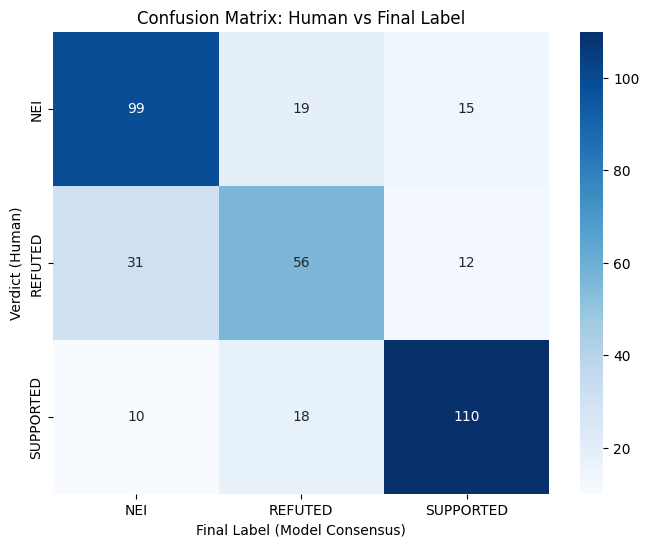

In [1]:
import pandas as pd
import json
from sklearn.metrics import cohen_kappa_score

# ==========================================
# PHẦN 1: LOAD VÀ CHUẨN HÓA DỮ LIỆU
# ==========================================
def load_and_prep():
    with open('output_dataset.json', 'r', encoding='utf-8') as f:
        df_out = pd.DataFrame(json.load(f))
    with open('human_label_with_final.json', 'r', encoding='utf-8') as f:
        df_hum = pd.DataFrame(json.load(f))

    # Chuẩn hóa Claim để mapping không bị lệch
    df_out['claim_norm'] = df_out['claim'].str.strip().str.lower()
    df_hum['claim_norm'] = df_hum['claim'].str.strip().str.lower()
    print(df_out['final_label'].value_counts())
    
    # Hàm trích xuất và chuẩn hóa nhãn (Tránh lỗi hoa/thường)
    def get_vote(voter_details, model_name):
        for item in voter_details:
            if item['model'] == model_name:
                return str(item['vote']).strip().upper()
        return None

    # Trích xuất vote cho 3 model vào df_out
    models = {
        'gpt': 'openai/gpt-4o-mini',
        'qwen': 'qwen/qwen-2.5-72b-instruct',
        'mistral': 'mistralai/mistral-small-24b-instruct-2501'
    }
    
    for key, full_name in models.items():
        df_out[f'{key}_vote'] = df_out['voter_details'].apply(lambda x: get_vote(x, full_name))

    # Chuẩn hóa nhãn của Human
    df_hum['human_vote'] = df_hum['verdict'].str.strip().str.upper()

    # MERGE: Chỉ giữ lại các cột cần thiết để tính toán
    # Merge inner để lấy đúng 199 dòng mà cả người và máy đều có
   # Sửa lại phần MERGE trong hàm load_and_prep của bạn
    # Cập nhật lại phần MERGE trong hàm load_and_prep của bạn
    df_merged = pd.merge(
        df_hum[['claim_norm', 'human_vote']], 
        df_out[['claim_norm', 'final_label', 'status', 'gpt_vote', 'qwen_vote', 'mistral_vote']], # THÊM 'status' Ở ĐÂY
        on='claim_norm', 
        how='inner'
    )
    
    return df_out, df_merged

df_full, df_human_subset = load_and_prep()

# ==========================================
# PHẦN 2: TÍNH TOÁN KAPPA
# ==========================================
results = []

def calculate_kappa(df, rater1, rater2, category):
    # Loại bỏ các dòng bị thiếu của 1 trong 2 rater
    data = df[[rater1, rater2]].dropna()
    if len(data) > 0:
        score = cohen_kappa_score(data[rater1], data[rater2])
        results.append({
            'Category': category,
            'Pair': f"{rater1} vs {rater2}",
            'Kappa': round(score, 4),
            'Samples': len(data)
        })

# 1. Model vs Model (Tính trên toàn bộ dataset cho khách quan)
model_pairs = [('gpt_vote', 'qwen_vote'), ('gpt_vote', 'mistral_vote'), ('qwen_vote', 'mistral_vote')]
for m1, m2 in model_pairs:
    calculate_kappa(df_full, m1, m2, "Model vs Model")

# 2. Human vs Model (Chỉ tính trên 199 dòng đã merge)
for m in ['gpt_vote', 'qwen_vote', 'mistral_vote']:
    calculate_kappa(df_human_subset, 'human_vote', m, "Human vs Model")

# ==========================================
# PHẦN 3: HIỂN THỊ KẾT QUẢ
# ==========================================
report_df = pd.DataFrame(results)
print("--- KAPPA SCORE REPORT ---")
print(report_df.to_string(index=False))

# Gợi ý: Kiểm tra phân phối nhãn của Human vs Model
print("\n--- Label Distribution (Human vs GPT) ---")
print(df_human_subset[['human_vote', 'gpt_vote']].apply(pd.Series.value_counts))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# Giả sử bạn đã có df_human_subset từ bước merge trước đó
# Nếu chưa, hãy đảm bảo df_human_subset có 2 cột: 'human_vote' và 'final_label'

def check_human_vs_final(df):
    # 1. Chuẩn hóa lại một lần nữa cho chắc chắn
    df['human_vote'] = df['human_vote'].str.strip().str.upper()
    df['final_label'] = df['final_label'].str.strip().str.upper()
    
    # 2. Tính toán các chỉ số cơ bản
    kappa = cohen_kappa_score(df['human_vote'], df['final_label'])
    
    print(f"--- THỐNG KÊ ĐỐI CHIẾU ---")
    print(f"Số lượng mẫu đối chiếu: {len(df)}")
    print(f"Chỉ số Cohen's Kappa: {kappa:.4f}")
    print("\n--- BẢO CÁO CHI TIẾT (Classification Report) ---")
    print(classification_report(df['human_vote'], df['final_label']))

    # 3. Vẽ Confusion Matrix
    labels = sorted(df['human_vote'].unique())
    cm = confusion_matrix(df['human_vote'], df['final_label'], labels=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Final Label (Model Consensus)')
    plt.ylabel('Verdict (Human)')
    plt.title('Confusion Matrix: Human vs Final Label')
    plt.show()

    # 4. Xuất các câu "Cãi nhau" ra để soi lỗi
    mismatch = df[df['human_vote'] != df['final_label']]
    return mismatch

# 1. Chuẩn hóa nhãn final_label trong tập subset
# Thêm .str trước .upper()
df_human_subset['final_label'] = df_human_subset['final_label'].str.strip().str.upper()

# 2. Gọi hàm đối chiếu mà bạn đã viết
df_mismatch = check_human_vs_final(df_human_subset)

# # 3. In ra 5 ví dụ "cãi nhau" điển hình để phân tích
# print("\n--- CÁC VÍ DỤ LỆCH NHÃN (MISMATCH EXAMPLES) ---")
# pd.set_option('display.max_colwidth', 150) # Để đọc được claim dài
# cols_to_show = ['claim_norm', 'human_vote', 'final_label', 'gpt_vote', 'qwen_vote', 'mistral_vote']


--- CHỈ SỐ CHI TIẾT THEO NHÃN ---
           precision  recall  f1-score
NEI           0.7071  0.7444    0.7253
REFUTED       0.6022  0.5657    0.5833
SUPPORTED     0.8029  0.7971    0.8000


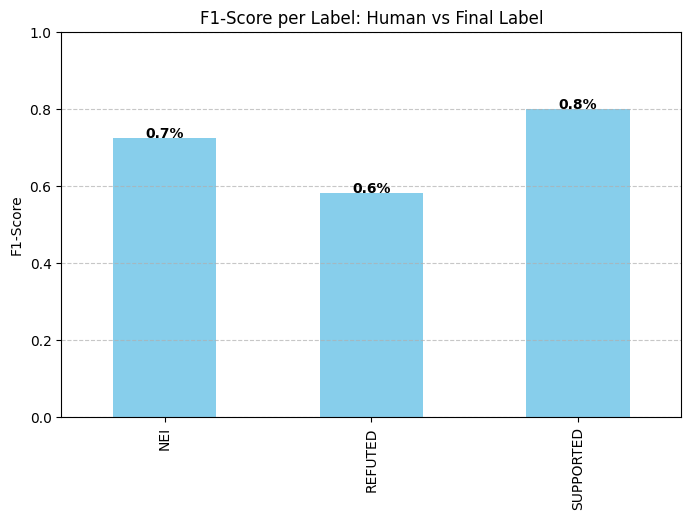

In [2]:
import pandas as pd
from sklearn.metrics import classification_report

def label_performance_analysis(df):
    # Đảm bảo nhãn đã chuẩn hóa
    y_true = df['human_vote'].str.strip().str.upper()
    y_pred = df['final_label'].str.strip().str.upper()
    
    # Trích xuất báo cáo dưới dạng dictionary để đưa vào DataFrame
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    
    # Chuyển thành DataFrame và lọc bỏ các dòng tổng hợp (accuracy, macro, weighted)
    df_labels = pd.DataFrame(report_dict).transpose()
    df_labels = df_labels.loc[['NEI', 'REFUTED', 'SUPPORTED']]
    
    print("--- CHỈ SỐ CHI TIẾT THEO NHÃN ---")
    print(df_labels[['precision', 'recall', 'f1-score']].round(4))
    
    # Vẽ biểu đồ cột để so sánh F1-score
    df_labels['f1-score'].plot(kind='bar', color='skyblue', figsize=(8, 5))
    plt.title('F1-Score per Label: Human vs Final Label')
    plt.ylabel('F1-Score')
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(df_labels['f1-score']):
        plt.text(i, v, f"{v:.1f}%", ha='center', fontweight='bold')

    plt.show()

# Chạy hàm
label_performance_analysis(df_human_subset)

--- TỶ LỆ KHỚP VỚI NGƯỜI THEO ĐỘ TỰ TIN ---
status
HIGH_CONFIDENCE      81.52%
MEDIUM_CONFIDENCE    61.83%
Name: is_correct, dtype: object


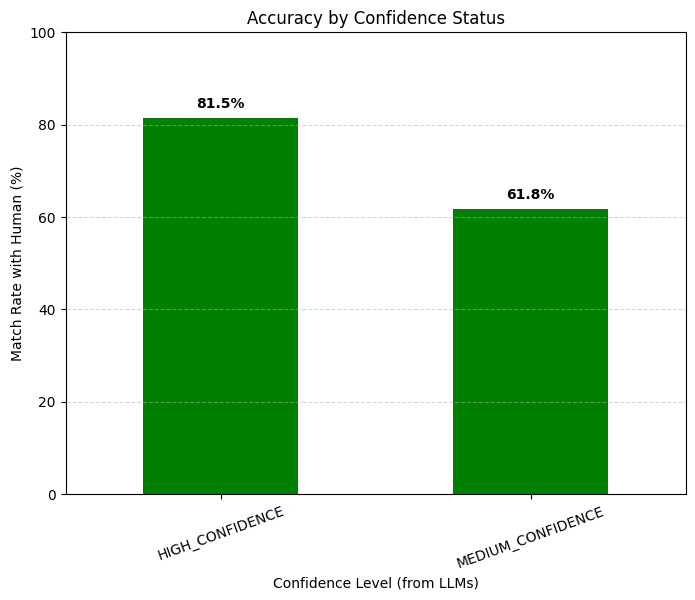

In [3]:
import matplotlib.pyplot as plt

def confidence_accuracy_analysis(df):
    # Tạo cột đánh giá đúng/sai (so với con người)
    df['is_correct'] = (df['human_vote'].str.strip().str.upper() == 
                        df['final_label'].str.strip().str.upper())
    
    # Tính Accuracy theo từng nhóm status
    calibration = df.groupby('status')['is_correct'].mean() * 100
    
    # Sắp xếp theo thứ tự logic nếu cần
    if 'HIGH_CONFIDENCE' in calibration and 'MEDIUM_CONFIDENCE' in calibration:
        calibration = calibration.loc[['HIGH_CONFIDENCE', 'MEDIUM_CONFIDENCE']]
    
    print("--- TỶ LỆ KHỚP VỚI NGƯỜI THEO ĐỘ TỰ TIN ---")
    print(calibration.round(2).astype(str) + '%')
    
    # Vẽ biểu đồ
    plt.figure(figsize=(8, 6))
    colors = ['green' if x > 60 else 'orange' for x in calibration]
    calibration.plot(kind='bar', color=colors)
    
    plt.title('Accuracy by Confidence Status')
    plt.ylabel('Match Rate with Human (%)')
    plt.xlabel('Confidence Level (from LLMs)')
    plt.ylim(0, 100)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Thêm nhãn số trên đầu cột
    for i, v in enumerate(calibration):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
    
    plt.show()

# Chạy hàm
confidence_accuracy_analysis(df_human_subset)

In [ ]:
import pandas as pd

# 1. Load dữ liệu
df = pd.read_json("human_label_with_final.json")

# 2. Lọc ra những data có status là HIGH_CONFIDENCE
df_high = df[df['status'] == 'HIGH_CONFIDENCE']

# 3. Kiểm tra số lượng sau khi lọc
print(f"Số lượng mẫu High Confidence: {len(df_high)}")

# 4. (Tùy chọn) Lưu ra file mới để sử dụng
# df_high.to_json("high_confidence_only.json", orient='records', force_ascii=False, indent=4)

Số lượng mẫu High Confidence: 184
